### Testing space for uMux model

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from uMux_modeling.include.model import *

In [7]:

loaded_data = np.loadtxt('NIST_full_s21.txt', dtype=complex)

freqs_loaded = np.real(loaded_data[:, 0])
s21_loaded = loaded_data[:, 1]
s21_db_loaded = np.abs(s21_loaded) 
s21_phase = np.angle(s21_loaded)
s21_logMag = 20*np.log10(s21_db_loaded)
s21_logMag = s21_logMag-np.max(s21_logMag)



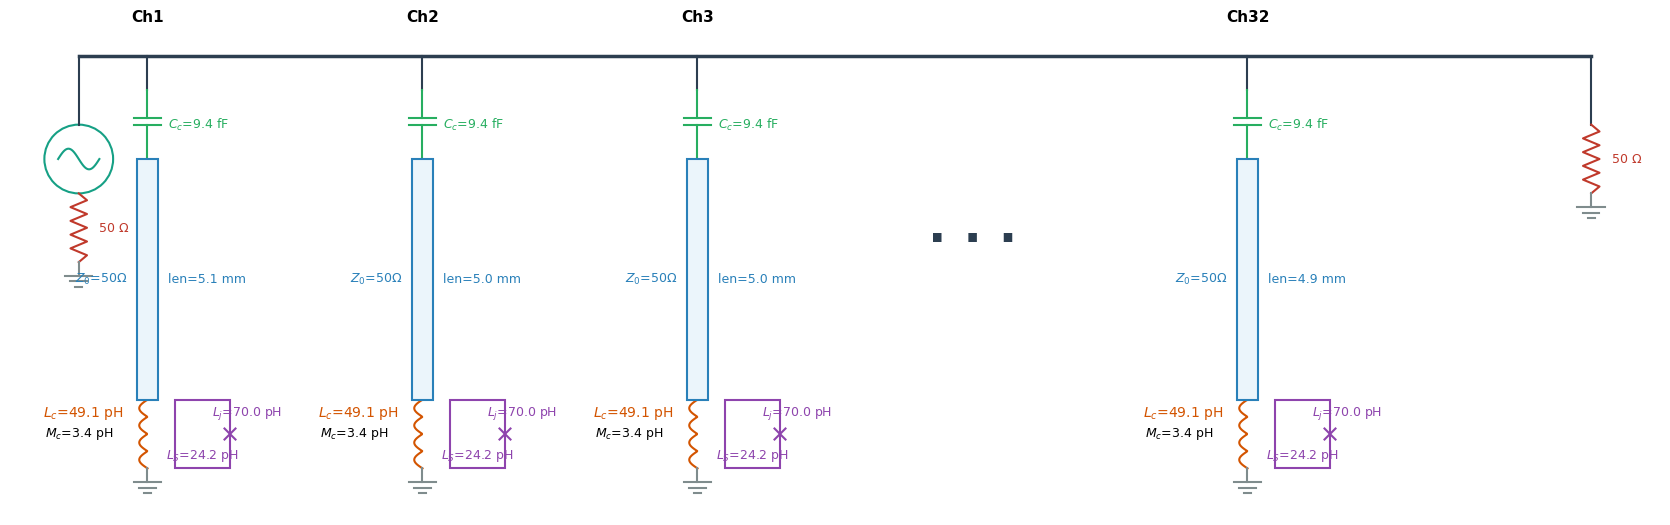

In [ ]:
loaded_params = np.loadtxt('NIST_full_params.txt', dtype=float)

VNA = VNA_Simulator(z0=50)
Phi0 = 2.067e-15

# Keep a list of your SQUIDs so you can easily access and tune them later
squids = []

count = 1
for params in loaded_params:
    # 1. DESIGN PHASE: Create unique components for THIS channel
    # We set phi_ext=0 as our baseline "design flux"

    squid_ch = SQUID(L_j=70e-12, L_s=24.2e-12, phi_ext=0)
    squid_ch.add_flux_line("FluxRamp", 15e-12)
    squid_ch.add_flux_line("Input", 246e-12)   
    ind_ch = Inductor(49.1e-12)
    tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)
    
    # Save the SQUID reference so we can change its flux later
    squids.append(squid_ch)

    # 2. EXTRACT PHYSICAL PARAMS: Calculate length based on the baseline 0-flux state
    length, Cc_val, Qi_val = extract_physical_params(params, tuned_L_ch, Cc_in=9.4e-15)
    
    # 3. BUILD PHASE: Lock in the physical parameters
    cap_ch = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val)

    # Add to channel and VNA
    channel = Channel(name=f"Ch{count}")
    channel.add(cap_ch)
    channel.add(phys_res)
    VNA.add(channel, 'shunt')
    
    count += 1

VNA.draw_schematic(use_color=True)

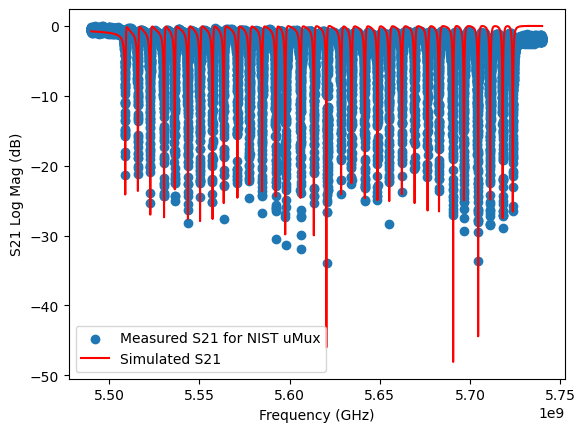

In [9]:


S = VNA.get_s_matrix(freqs_loaded)

plt.scatter(freqs_loaded, s21_logMag, label = "Measured S21 for NIST uMux")
plt.plot(freqs_loaded, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.legend()
# plt.xlim([5.6e9,5.61e9])
plt.show()

# plt.scatter(freqs_loaded, s21_phase)
# plt.plot(freqs_loaded, np.angle(S[1,0]), color = 'r')
# plt.show()

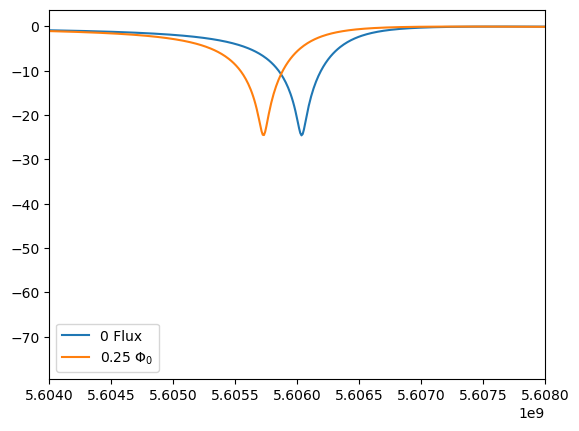

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define a frequency sweep around the first channel's expected resonance
f_sweep = freqs_loaded
# 1. Measure at Baseline (0 Flux)
s_matrix_baseline = VNA.get_s_matrix(f_sweep)
s21_baseline = 20 * np.log10(np.abs(s_matrix_baseline[1, 0, :]))

# 2. OPERATION PHASE: Apply flux to the first channel's SQUID
for sq in squids:
    sq.set_flux(0.5 * Phi0) 

# 3. Measure after applying flux
s_matrix_shifted = VNA.get_s_matrix(f_sweep)
s21_shifted = 20 * np.log10(np.abs(s_matrix_shifted[1, 0, :]))

# Plot the results
plt.plot(f_sweep, s21_baseline, label='0 Flux')
plt.plot(f_sweep, s21_shifted, label='0.25 $\Phi_0$')
plt.legend()
plt.xlim([5.604e9,5.608e9])
plt.show()